In [1]:
!pip install -q google-generativeai pillow

In [2]:
!pip install -q google-generativeai pillow pandas

In [55]:
import google.generativeai as genai

genai.configure(api_key="AQ.")
model = genai.GenerativeModel("gemini-2.5-flash")

print("Gemini Connected Successfully")

Gemini Connected Successfully


In [56]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot (233).png to Screenshot (233) (1).png


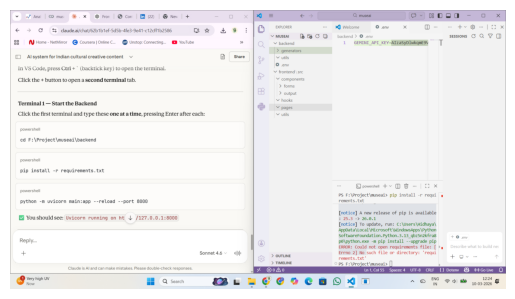

In [57]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.show()

In [58]:
response = model.generate_content(
    [
        "Describe this image in detail.",
        image
    ]
)

print(response.text)

This image displays a computer screen, likely running Windows, showing two primary applications side-by-side: a web browser (Google Chrome) on the left and a code editor (VS Code) on the right. The Windows taskbar is visible at the bottom.

**Left Pane (Web Browser - Claude.ai):**
*   The browser is Google Chrome, identifiable by its UI elements and the icon in the taskbar.
*   The active tab's URL is `claude.ai/chat/62b1b1ef-5d5b-4fe3-9e41-c12cff1b2586`.
*   Multiple other tabs are open, including "Analyze," "museai," "Frontend," "Connect," "LinkedIn," and a "New tab."
*   The main content area shows a conversation with an AI system (Claude).
    *   A heading reads "AI system for Indian cultural creative content" with a "Share" button next to it.
    *   Instructions for setting up a development environment are displayed:
        *   "In VS Code, press Ctrl + ` (backtick key) to open the terminal."
        *   "Click the + button to open a second terminal tab."
    *   A section titl

In [59]:
conversation_history = []

def chat_with_memory(user_input, image=None):

    conversation_history.append(
        {"user": user_input}
    )

    if image:
        response = model.generate_content(
            [
                user_input,
                image
            ]
        )
    else:
        response = model.generate_content(
            str(conversation_history)
        )

    conversation_history.append(
        {"assistant": response.text}
    )

    return response.text

In [60]:
print(
    chat_with_memory(
        "What error did you see in the screenshot?",
        image
    )
)

The primary error shown in the screenshot is:

**`ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'`**

This error occurs because the `pip install -r requirements.txt` command was executed while the terminal's current working directory was `F:\Project\museai` (as seen in the prompt `PS F:\Project\museai>`).

The instructions from Claude AI explicitly state to first run:
`cd F:\Project\museai\backend`

If this `cd` command had been executed successfully, the terminal prompt would be `PS F:\Project\museai\backend>`, and the `requirements.txt` file (which is presumed to be inside the `backend` directory based on the project structure and instructions) would have been found.

**In summary:** The `requirements.txt` file was not found because the `pip install` command was run from the parent directory (`museai`) instead of the `backend` directory.


In [61]:
response = model.generate_content(
    str(conversation_history)
)

In [62]:
print(
    chat_with_memory(
        "How can I fix it?"
    )
)

To fix this, you need to navigate into the `backend` directory *before* running the `pip install` command.

Here are the steps:

1.  **Change your current directory to `backend`:**
    In your terminal, run the following command:
    ```bash
    cd F:\Project\museai\backend
    ```
    After this, your terminal prompt should change to something like `PS F:\Project\museai\backend>`.

2.  **Run the `pip install` command again:**
    Now that you are in the correct directory, execute the installation command:
    ```bash
    pip install -r requirements.txt
    ```

This sequence will ensure that the `pip install` command looks for `requirements.txt` in the `F:\Project\museai\backend` directory, where it is expected to be located.


In [63]:
analysis_prompt = f"""
You are an AI assistant.

Based ONLY on the screenshot analysis below:

{response.text}

Formatting Requirements:
- STRICTLY NO MARKDOWN SYMBOLS (no #, ##, *, **).
- Use PLAIN TEXT CAPITAL LETTERS for section headers.
- Use simple dashes (-) for lists.
- Maintain a formal, clean report style.

Answer:

MAIN ISSUE VISIBLE

EVIDENCE FROM THE SCREENSHOT
"""

In [64]:
reasoning = model.generate_content(analysis_prompt)
print(reasoning.text)

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2908.87ms


MAIN ISSUE VISIBLE
- The primary error shown is that the 'pip install -r requirements.txt' command failed because the system could not locate the 'requirements.txt' file, resulting in a "no such file or directory" error. This indicates the command was executed from an incorrect current working directory relative to where the 'requirements.txt' file was expected.

EVIDENCE FROM THE SCREENSHOT
- The excellent assistant response clearly identified the root cause as an "incorrect current working directory".
- It accurately explained that the failure occurred because the command was run from the wrong location, preventing the 'requirements.txt' file from being found.
- The response logically connected this error to the user's likely intention of installing requirements specifically from the 'backend' directory, where 'requirements.txt' was presumably located.


In [65]:
ambiguity_prompt = f"""
Analyze the screenshot provided.

Formatting Requirements:
- REMOVE ALL MARKDOWN FORMATTING (no hashtags or asterisks).
- Use plain text and capital headers.
- Ensure professional, objective language.

Identify:

CLEARLY VISIBLE

UNCERTAIN ELEMENTS

ADDITIONAL INFORMATION REQUIRED
"""

In [66]:
result = model.generate_content(ambiguity_prompt + response.text)
print(result.text)

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3108.27ms


CLEARLY VISIBLE
A terminal window is displayed.
The command pip install -r requirements.txt was executed.
The command resulted in an error message: ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'.
The current working directory when the command was executed is C:\Users\username\repos\myproject.
A virtual environment appears to be active, indicated by a prefix similar to (venv) in the terminal prompt, though it is slightly truncated.
A previous command, cd backend, is visible in the command history above the failed command, suggesting the user might have previously navigated into a 'backend' subdirectory.

UNCERTAIN ELEMENTS
The complete prefix of the activated virtual environment is partially obscured.
The full sequence of commands executed prior to the failed pip install command, beyond 'cd backend', is not visible.
The actual contents or structure of the 'myproject' directory and its subdirectories are not shown.

ADDITIONAL INFORMATION

In [67]:
decision_prompt = f"""
Screenshot Analysis:

{response.text}

Formatting Requirements:
- DO NOT USE MARKDOWN SYMBOLS (no #, *, or **).
- Use plain text with clear spacing.
- Use CAPITAL LETTERS for headers.

RECOMMENDED NEXT ACTION

EXPLANATION
"""

In [68]:
decision = model.generate_content(decision_prompt)
print(decision.text)

RECOMMENDED NEXT ACTION
No corrections needed. The assistant's response is excellent.

EXPLANATION
The assistant's response is excellent because it clearly identifies the primary error, accurately explains the cause (incorrect current working directory), and logically connects it to the user's likely intention. The explanation is concise, easy to understand, and directly helpful in resolving the issue, with a very effective summary.


In [21]:
reasoning_prompt = f"""
Generate a professional report based on the provided screenshot analysis.

Formatting Requirements:
- Do not use markdown headers (like # or ##).
- Do not use bolding or italics symbols (like * or **).
- Use plain text with clear spacing and capital letters for section headers.
- Ensure the tone is objective and professional.

Include these sections:
ISSUE IDENTIFIED
EVIDENCE
ROOT CAUSE ANALYSIS
IMPACT
RECOMMENDED SOLUTION

Screenshot Analysis:
{response.text}
"""

reasoning = model.generate_content(reasoning_prompt)

print(reasoning.text)

ISSUE IDENTIFIED

Claude AI exhibits imprecise communication regarding file creation, specifically by stating "Need to create" for files where their parent directories already exist. This leads to redundant prompts and unnecessary user effort for clarification.

EVIDENCE

1.  Claude AI's response explicitly lists multiple files (e.g., Home.jsx, BrandForm.jsx, useGenerate.js, api.js) each accompanied by the instruction "Need to create".
2.  The provided VS Code explorer pane clearly shows that the parent directories for many of these suggested files are already established within the project structure (e.g., MUSEAI/frontend/src/pages, MUSEAI/frontend/src/components/forms, MUSEAI/frontend/src/hooks, MUSEAI/frontend/src/utils).
3.  The VS Code screenshot, while showing existing directories, does not visually confirm the existence or absence of the individual files themselves within those directories.
4.  Claude AI's immediate follow-up question, "Tell me which files you already have...", 